# Phase 3 — Execution & Cost Analysis

**Goal**: Apply transaction cost models to the position sizing results from Phase 2
and answer the critical question: *which strategies survive after costs?*

## Design note — Long-Only default

Phase 2 discovered the **forced-short problem**: setting `n_short=10` forces the
portfolio to short 10 stocks even when the signal says they're merely weaker longs.
We now default to **long-only** (`n_short=0`), which matches `AlphaConfig`'s new
`portfolio_mode="long_only"` default.  All cost / turnover analysis below uses the
long-only portfolios.

## Hypothesis

Signal-Weighted had the best gross Sharpe in `risk_analysis.ipynb`, but it may
also have significant turnover.  After realistic costs (3–5 bps for large-cap
US equities), the ranking may change.

## What we'll do

1. **Rebuild** the 4 position sizing portfolios from Phase 2 (long-only)
2. **Measure turnover** for each method
3. **Apply cost models** (fixed, spread, sqrt-impact)
4. **Sharpe vs cost curve** — find the breakeven cost for each method
5. **Net-of-cost comparison** — which method wins after costs?
6. **Rebalancing frequency sweep** — can less frequent trading help?
7. **Sub-period stability** — is the winner consistent across time?
8. **Reflection** — what we learned

## Key insight we're testing

> "Position sizing matters as much as alpha" was our Phase 2 finding.
> Phase 3 adds: "Turnover is the hidden cost that can kill a strategy."

---

## 1. Setup

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"Project root: {PROJECT_ROOT}")
print(f"src added to path: {SRC_DIR}")

Project root: /home/jerryhong/code-projects/quant101
src added to path: /home/jerryhong/code-projects/quant101/src


In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from data.universe import get_universe
from data.loader.data_loader import stock_load_process
from indicators.registry import get_indicator
from alpha.forward_returns import compute_forward_returns
from alpha.preprocessing import preprocess_factor
from alpha.combination import combine_factors

from risk.risk_metrics import risk_summary, max_drawdown, drawdown_series
from risk.position_sizing import (
    size_equal_weight, size_inverse_volatility,
    size_volatility_target, size_signal_weighted,
    compute_realized_volatility,
)

from execution.cost_model import (
    FixedCostModel, SpreadCostModel, SqrtImpactCostModel, CompositeCostModel,
)
from execution.cost_analysis import (
    compute_turnover, compute_net_returns,
    sharpe_vs_cost_curve, breakeven_cost,
)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("Imports OK ✅")

Imports OK ✅


## 2. Rebuild Portfolios (from Phase 2) — Long-Only

We reconstruct the same composite factor (BBIBOLL + Vol Ratio) and the 4 sizing
methods with `n_short=0` (long-only mode).  This is a copy from `risk_analysis.ipynb`
— in a production codebase we'd factor this into a shared pipeline, but for a
learning project, explicit repetition makes each notebook self-contained.

In [4]:
# ── Universe & date range ──
UNIVERSE = get_universe("US_LARGE_CAP_50")
START_DATE = "2023-01-01"
END_DATE = "2026-02-28"
N_QUANTILES = 5

# ── Load OHLCV ──
ohlcv = stock_load_process(tickers=UNIVERSE, start_date=START_DATE, end_date=END_DATE).collect()
print(f"OHLCV: {ohlcv.shape[0]:,} rows, {ohlcv['ticker'].n_unique()} tickers")

Loading from cache: /mnt/blackdisk/quant_data/polygon_data/processed/us_stocks_sip/day_aggs_v1/cache_c5e11349e9e04e8bdef2634ae48ac375.parquet
Cache loaded: 40,301 rows, 2.58 MB
OHLCV: 40,301 rows, 52 tickers


In [5]:
# ── Build composite factor (BBIBOLL + Vol Ratio) ──
# Exact same pipeline as risk_analysis.ipynb

# --- BBIBOLL factor ---
bbiboll_fn = get_indicator("bbiboll")
ohlcv_bb = bbiboll_fn(ohlcv)

bbi_df = (
    ohlcv_bb
    .with_columns(
        ((pl.col("close") - pl.col("bbi")) / pl.col("dev")).alias("value"),
    )
    .filter(pl.col("value").is_not_null() & pl.col("value").is_not_nan() & pl.col("value").is_finite())
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("value")])
)
bbi_clean = preprocess_factor(bbi_df, winsorize_pct=0.01, method="zscore", neutralize=[])

# --- Vol Ratio factor ---
vol_df = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1).over("ticker")).log().alias("log_ret")
    )
    .with_columns([
        pl.col("log_ret").rolling_std(window_size=5).over("ticker").alias("vol_5d"),
        pl.col("log_ret").rolling_std(window_size=20).over("ticker").alias("vol_20d"),
    ])
    .with_columns((pl.col("vol_5d") / pl.col("vol_20d")).alias("value"))
    .filter(
        pl.col("value").is_not_null() & pl.col("value").is_not_nan()
        & pl.col("value").is_finite() & (pl.col("vol_20d") > 1e-8)
    )
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("value")])
)
vol_clean = preprocess_factor(vol_df, winsorize_pct=0.01, method="zscore", neutralize=[])

# --- Composite: BBIBOLL + Vol Ratio (equal-weight) ---
composite = combine_factors(
    factors=[bbi_clean, vol_clean],
    method="equal_weight",
)
print(f"Composite factor: {composite.shape[0]:,} signal rows")

Composite factor: 38,585 signal rows


In [ ]:
# ── Compute daily returns & next-day returns ──
daily_returns = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1).over("ticker") - 1).alias("daily_return")
    )
    .filter(pl.col("daily_return").is_not_null() & pl.col("daily_return").is_finite())
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("daily_return")])
)

next_day_returns = (
    daily_returns
    .sort(["ticker", "date"])
    .with_columns(
        pl.col("daily_return").shift(-1).over("ticker").alias("next_day_return")
    )
    .filter(pl.col("next_day_return").is_not_null())
    .select(["date", "ticker", "next_day_return"])
)

# For Signal-Weighted
returns_for_sw = (
    daily_returns
    .rename({"daily_return": "return"})
)

# Realized volatility for sizing
vol_estimates = compute_realized_volatility(ohlcv, window=20)

print(f"Daily returns: {daily_returns.shape[0]:,} rows")
print(f"Next-day returns: {next_day_returns.shape[0]:,} rows")
print(f"Volatility estimates: {vol_estimates.shape[0]:,} rows")

Daily returns: 40,249 rows
Next-day returns: 40,197 rows
Volatility estimates: 39,261 rows


In [ ]:
# ── Generate weights for all 4 sizing methods (long-only: n_short=0) ──
w_ew = size_equal_weight(composite, n_long=10, n_short=0)
w_iv = size_inverse_volatility(composite, vol_estimates, n_long=10, n_short=0)
w_vt = size_volatility_target(composite, vol_estimates, target_vol=0.10, n_long=10, n_short=0)
w_sw = size_signal_weighted(composite, returns_for_sw, lookback=60, max_position=0.10)

sizing_methods = {
    "Equal-Weight": w_ew,
    "Inverse-Vol": w_iv,
    "Vol-Target (10%)": w_vt,
    "Signal-Weighted": w_sw,
}

for name, w in sizing_methods.items():
    print(f"{name:20s}: {w.shape[0]:,} position-days, {w['date'].n_unique()} dates")

Equal-Weight        : 7,570 position-days, 757 dates
Inverse-Vol         : 7,570 position-days, 757 dates
Vol-Target (10%)    : 7,570 position-days, 757 dates
Signal-Weighted     : 14,581 position-days, 730 dates


## 3. Turnover Analysis

Turnover tells you how much of the portfolio you're replacing each day.
High turnover × high cost = performance drag.

Rule of thumb for a long-only factor strategy:
- Annual turnover < 100%: Good (slow signal, e.g. value)
- Annual turnover 100–300%: Moderate (momentum, mean-reversion)
- Annual turnover > 300%: Expensive (needs very low cost or very high alpha)

Equal-Weight        : avg daily turnover = 0.3823, annual = 96.3% (9633% two-way)
Inverse-Vol         : avg daily turnover = 0.4194, annual = 105.7% (10568% two-way)
Vol-Target (10%)    : avg daily turnover = 0.5802, annual = 146.2% (14621% two-way)
Signal-Weighted     : avg daily turnover = 0.3842, annual = 96.8% (9683% two-way)


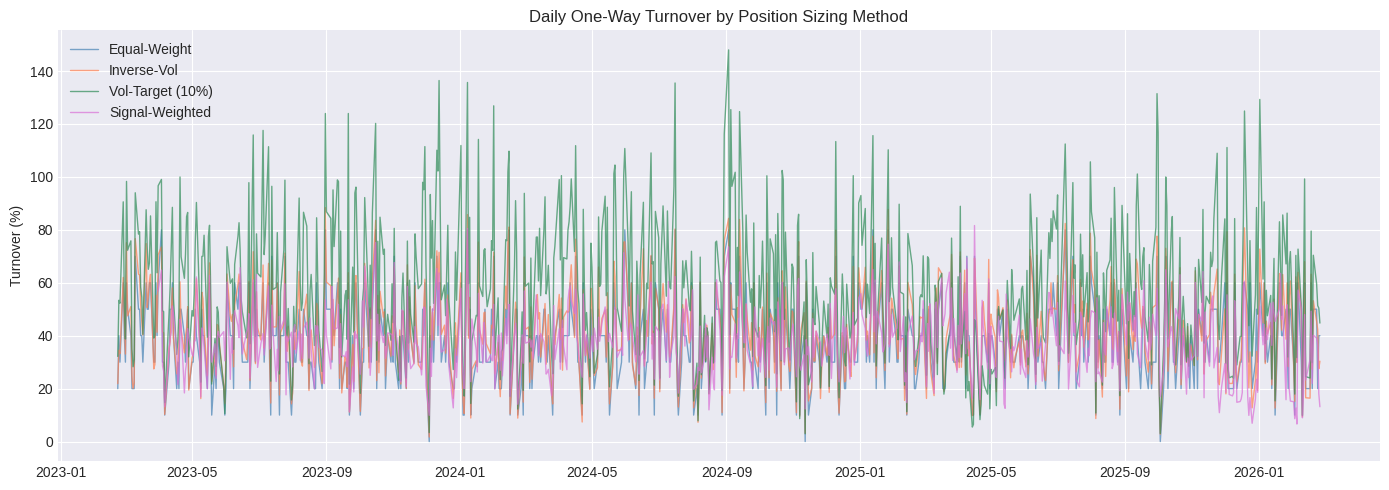

In [9]:
# ── Compute turnover for each method ──
turnovers = {}
for name, w in sizing_methods.items():
    to_df = compute_turnover(w)
    turnovers[name] = to_df
    to_arr = to_df["turnover"].to_numpy()
    avg_daily = np.mean(to_arr)
    annual = avg_daily * 252
    print(f"{name:20s}: avg daily turnover = {avg_daily:.4f}, "
          f"annual = {annual:.1f}% ({annual*100:.0f}% two-way)")

# Plot turnover time series
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["steelblue", "coral", "seagreen", "orchid"]
for (name, to_df), color in zip(turnovers.items(), colors):
    dates = to_df["date"].to_list()
    vals = to_df["turnover"].to_numpy()
    ax.plot(dates, vals * 100, label=name, color=color, alpha=0.7, linewidth=1)

ax.set_title("Daily One-Way Turnover by Position Sizing Method")
ax.set_ylabel("Turnover (%)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Gross vs Net Portfolio Returns

Now we compute portfolio returns and apply a baseline cost assumption.

**Baseline cost**: 5 bps fixed cost per dollar traded.  This is a
reasonable all-in estimate for large-cap US equities (commission +
half-spread), but underestimates market impact for concentrated trades.

In [10]:
# ── Compute gross portfolio returns, then net ──
def compute_portfolio_return(
    weights_df: pl.DataFrame, returns_df: pl.DataFrame, ret_col: str = "next_day_return"
) -> pl.DataFrame:
    """Join weights with next-day returns, compute weighted portfolio return per date."""
    return (
        weights_df
        .join(returns_df, on=["date", "ticker"], how="inner")
        .with_columns((pl.col("weight") * pl.col(ret_col)).alias("weighted_return"))
        .group_by("date")
        .agg(pl.col("weighted_return").sum().alias("port_return"))
        .sort("date")
    )

COST_BPS = 5.0
cost_model = FixedCostModel(cost_bps=COST_BPS)

results = {}
print(f"{'Method':<20s} {'Gross SR':>10s} {'Net SR':>10s} {'Δ SR':>8s} {'Ann TO':>10s}")
print("-" * 62)

for name, weights in sizing_methods.items():
    # Gross returns
    pr = compute_portfolio_return(weights, next_day_returns)

    # Turnover — cast date to match type before join
    to_df = turnovers[name]
    target_dtype = pr["date"].dtype
    to_df_cast = to_df.with_columns(pl.col("date").cast(target_dtype))

    aligned = (
        pr
        .join(to_df_cast, on="date", how="inner")
        .sort("date")
    )

    gross_aligned = aligned["port_return"].to_numpy()
    to_arr = aligned["turnover"].to_numpy()
    aligned_dates = aligned["date"].to_list()

    # Net returns
    net_ret = compute_net_returns(gross_aligned, to_arr, cost_model)

    gross_sharpe = np.mean(gross_aligned) / np.std(gross_aligned, ddof=1) * np.sqrt(252) if np.std(gross_aligned) > 0 else 0
    net_sharpe = np.mean(net_ret) / np.std(net_ret, ddof=1) * np.sqrt(252) if np.std(net_ret) > 0 else 0
    ann_to = np.mean(to_arr) * 252

    results[name] = {
        "dates": aligned_dates,
        "gross_returns": gross_aligned,
        "net_returns": net_ret,
        "turnover": to_arr,
        "gross_sharpe": gross_sharpe,
        "net_sharpe": net_sharpe,
        "ann_turnover": ann_to,
    }

    delta = net_sharpe - gross_sharpe
    print(f"{name:<20s} {gross_sharpe:>10.3f} {net_sharpe:>10.3f} {delta:>+8.3f} {ann_to:>9.1f}%")

Method                 Gross SR     Net SR     Δ SR     Ann TO
--------------------------------------------------------------
Equal-Weight              1.629      1.338   -0.290      96.3%
Inverse-Vol               1.679      1.320   -0.359     105.7%
Vol-Target (10%)          1.661      1.283   -0.378     146.2%
Signal-Weighted           0.805      0.068   -0.737      96.9%


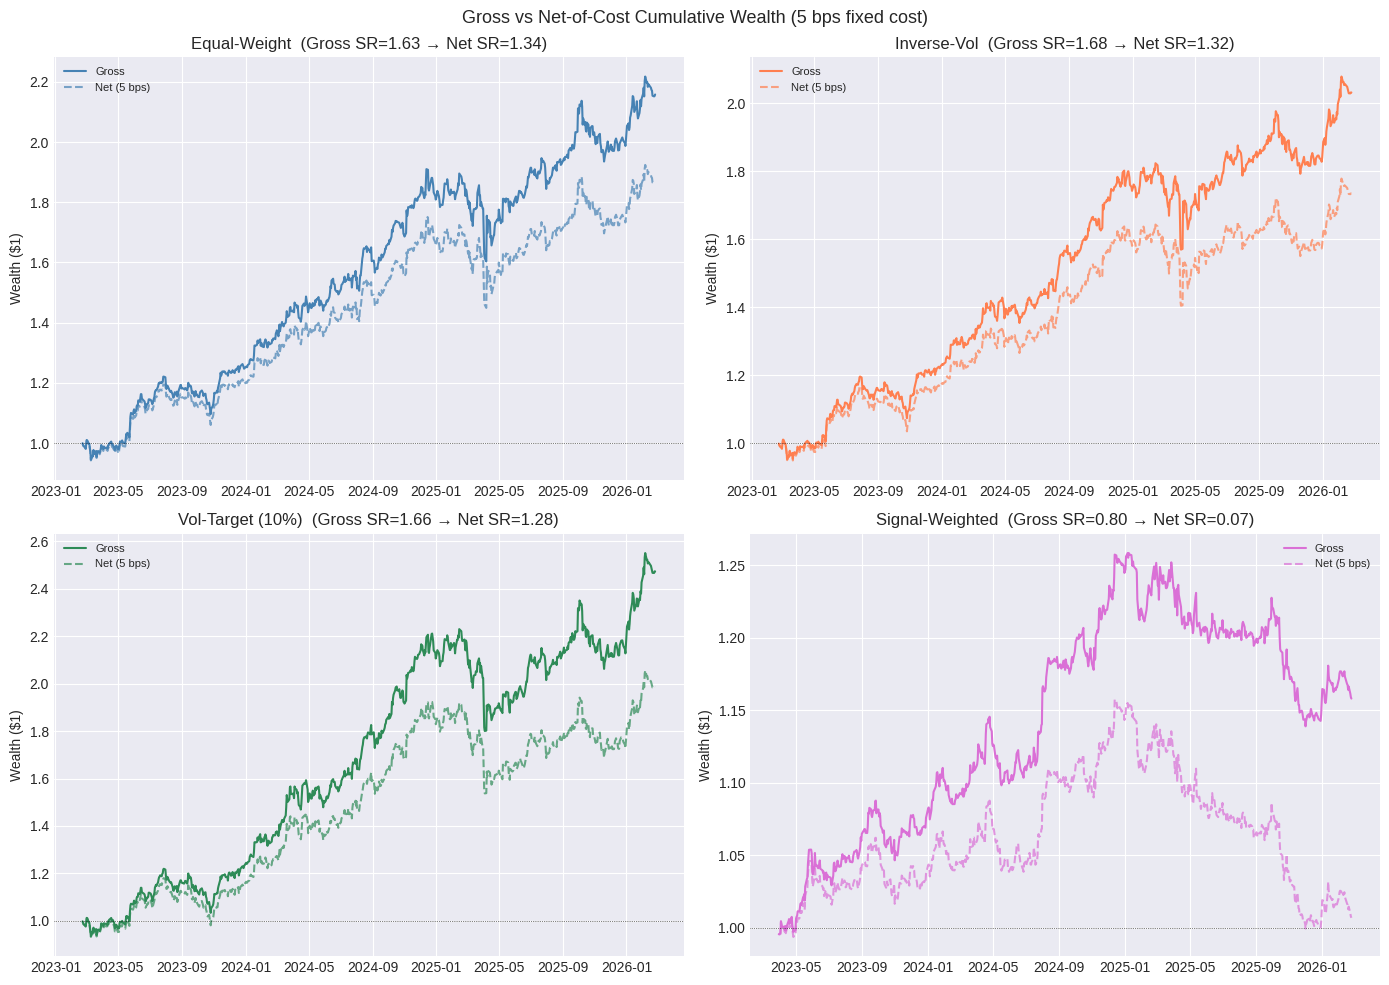

In [11]:
# ── Cumulative wealth: gross vs net ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, data), color in zip(axes.flat, results.items(), colors):
    gross_wealth = np.cumprod(1 + data["gross_returns"])
    net_wealth = np.cumprod(1 + data["net_returns"])

    ax.plot(data["dates"], gross_wealth, color=color, linewidth=1.5, label="Gross")
    ax.plot(data["dates"], net_wealth, color=color, linewidth=1.5, linestyle="--", alpha=0.7, label=f"Net ({COST_BPS:.0f} bps)")
    ax.axhline(1.0, color="black", linewidth=0.5, linestyle=":")
    ax.set_title(f"{name}  (Gross SR={data['gross_sharpe']:.2f} → Net SR={data['net_sharpe']:.2f})")
    ax.set_ylabel("Wealth ($1)")
    ax.legend(loc="best", fontsize=8)

plt.suptitle(f"Gross vs Net-of-Cost Cumulative Wealth ({COST_BPS:.0f} bps fixed cost)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Sharpe vs Cost Curve

The **Sharpe vs cost curve** shows how each strategy degrades as costs increase.
The slope depends on turnover: high-turnover strategies have steeper slopes.

The **breakeven cost** is where the curve crosses zero — the maximum cost the
strategy can tolerate and still be profitable.

Method                  Breakeven   Gross SR   Net@5bps
--------------------------------------------------------
Equal-Weight               28.1 bps      1.629      1.338
Inverse-Vol                23.4 bps      1.679      1.320
Vol-Target (10%)           21.9 bps      1.661      1.283
Signal-Weighted             5.4 bps      0.805      0.068


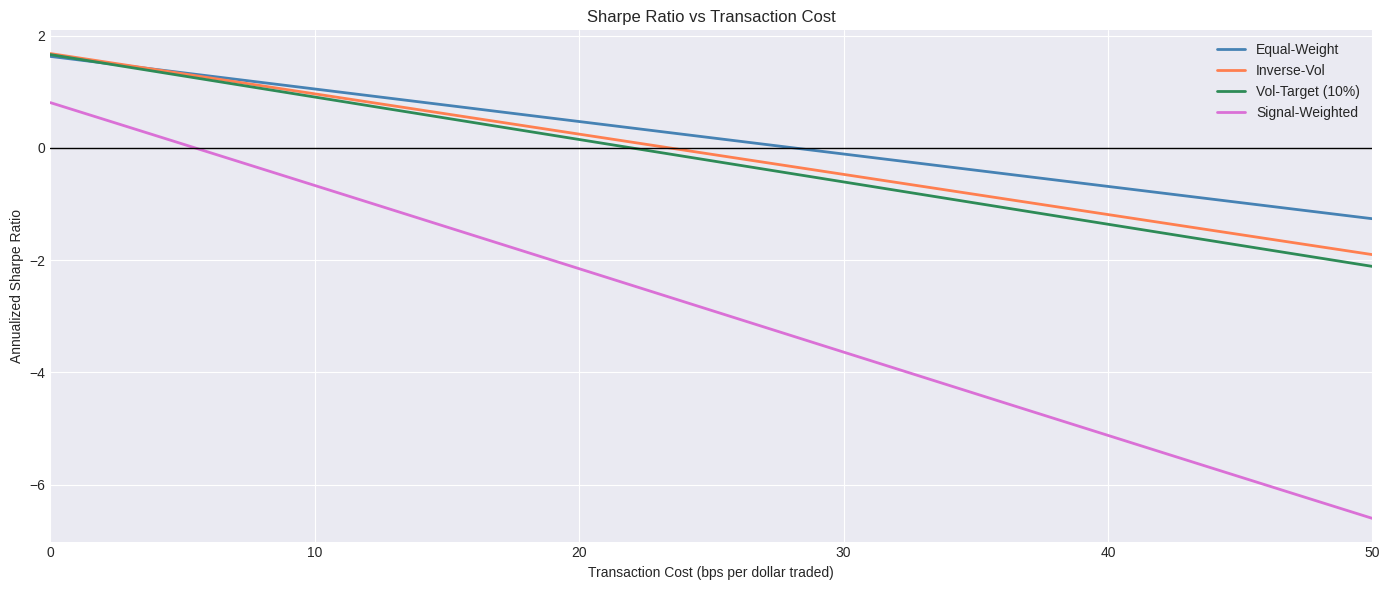

In [12]:
# ── Sharpe vs cost curve for each method ──
cost_range = np.arange(0, 51, 1, dtype=float)

fig, ax = plt.subplots(figsize=(14, 6))

print(f"{'Method':<20s} {'Breakeven':>12s} {'Gross SR':>10s} {'Net@5bps':>10s}")
print("-" * 56)

for (name, data), color in zip(results.items(), colors):
    curve = sharpe_vs_cost_curve(
        data["gross_returns"], data["turnover"],
        cost_bps_range=cost_range,
    )
    ax.plot(cost_range, curve["net_sharpe"], color=color, linewidth=2, label=name)

    be = breakeven_cost(data["gross_returns"], data["turnover"])
    print(f"{name:<20s} {be:>10.1f} bps {curve['gross_sharpe']:>10.3f} {data['net_sharpe']:>10.3f}")

ax.axhline(0, color="black", linewidth=1, linestyle="-")
ax.set_xlabel("Transaction Cost (bps per dollar traded)")
ax.set_ylabel("Annualized Sharpe Ratio")
ax.set_title("Sharpe Ratio vs Transaction Cost")
ax.legend()
ax.set_xlim(0, 50)
plt.tight_layout()
plt.show()

## 6. Net-of-Cost Comparison Table

A comprehensive table at multiple cost levels (0, 3, 5, 10 bps)
to see how the ranking shifts.

In [13]:
# ── Comprehensive net-of-cost comparison ──
cost_levels = [0, 3, 5, 10]

rows = []
for name, data in results.items():
    row = {"Method": name, "Ann. Turnover": f"{data['ann_turnover']:.0f}%"}
    be = breakeven_cost(data["gross_returns"], data["turnover"])
    row["Breakeven (bps)"] = f"{be:.1f}"
    for bps in cost_levels:
        if bps == 0:
            sr = data["gross_sharpe"]
        else:
            model = FixedCostModel(cost_bps=bps)
            net = compute_net_returns(data["gross_returns"], data["turnover"], model)
            sr = np.mean(net) / np.std(net, ddof=1) * np.sqrt(252) if np.std(net) > 0 else 0
        row[f"SR@{bps}bps"] = f"{sr:.3f}"
    rows.append(row)

comp_df = pl.DataFrame(rows)
print("\n📊 Net-of-Cost Sharpe Comparison:")
print(comp_df)


📊 Net-of-Cost Sharpe Comparison:
shape: (4, 7)
┌──────────────────┬───────────────┬─────────────────┬─────────┬─────────┬─────────┬──────────┐
│ Method           ┆ Ann. Turnover ┆ Breakeven (bps) ┆ SR@0bps ┆ SR@3bps ┆ SR@5bps ┆ SR@10bps │
│ ---              ┆ ---           ┆ ---             ┆ ---     ┆ ---     ┆ ---     ┆ ---      │
│ str              ┆ str           ┆ str             ┆ str     ┆ str     ┆ str     ┆ str      │
╞══════════════════╪═══════════════╪═════════════════╪═════════╪═════════╪═════════╪══════════╡
│ Equal-Weight     ┆ 96%           ┆ 28.1            ┆ 1.629   ┆ 1.454   ┆ 1.338   ┆ 1.048    │
│ Inverse-Vol      ┆ 106%          ┆ 23.4            ┆ 1.679   ┆ 1.464   ┆ 1.320   ┆ 0.962    │
│ Vol-Target (10%) ┆ 146%          ┆ 21.9            ┆ 1.661   ┆ 1.434   ┆ 1.283   ┆ 0.905    │
│ Signal-Weighted  ┆ 97%           ┆ 5.4             ┆ 0.805   ┆ 0.363   ┆ 0.068   ┆ -0.671   │
└──────────────────┴───────────────┴─────────────────┴─────────┴─────────┴─────────┴────

## 7. Cost Model Comparison: Fixed vs Spread+Impact

The fixed cost model is a useful first approximation, but a more realistic
model combines:
- **Half-spread**: ~2 bps for large-cap
- **Square-root market impact**: η × σ × √(participation)

Let's see if the composite model changes anything.

In [14]:
# ── Compare cost models: Fixed(5bps) vs Spread(2bps)+SqrtImpact ──
fixed_model = FixedCostModel(cost_bps=5.0)
composite_model = CompositeCostModel([
    SpreadCostModel(half_spread_bps=2.0),
    SqrtImpactCostModel(eta=0.10, default_volatility=0.02, default_adv=50_000_000),
])

print(f"Model 1: {fixed_model.describe()}")
print(f"Model 2: {composite_model.describe()}")
print()

print(f"{'Method':<20s} {'Fixed(5bp)':>12s} {'Spread+Impact':>14s} {'Difference':>12s}")
print("-" * 62)

for name, data in results.items():
    net_fixed = compute_net_returns(
        data["gross_returns"], data["turnover"], fixed_model
    )
    net_composite = compute_net_returns(
        data["gross_returns"], data["turnover"], composite_model
    )
    sr_fixed = np.mean(net_fixed) / np.std(net_fixed, ddof=1) * np.sqrt(252)
    sr_composite = np.mean(net_composite) / np.std(net_composite, ddof=1) * np.sqrt(252)
    diff = sr_composite - sr_fixed
    print(f"{name:<20s} {sr_fixed:>12.3f} {sr_composite:>14.3f} {diff:>+12.3f}")

Model 1: FixedCost(5.0 bps)
Model 2: Composite(SpreadCost(2.0 bps half-spread) + SqrtImpact(η=0.10, σ_default=0.020, ADV_default=$50,000,000))

Method                 Fixed(5bp)  Spread+Impact   Difference
--------------------------------------------------------------
Equal-Weight                1.338          1.512       +0.174
Inverse-Vol                 1.320          1.536       +0.215
Vol-Target (10%)            1.283          1.509       +0.227
Signal-Weighted             0.068          0.510       +0.442


## 8. Turnover vs Alpha: The Efficiency Frontier

Plot each method as a point in (turnover, net Sharpe) space.
The ideal strategy is in the upper-left: high Sharpe, low turnover.

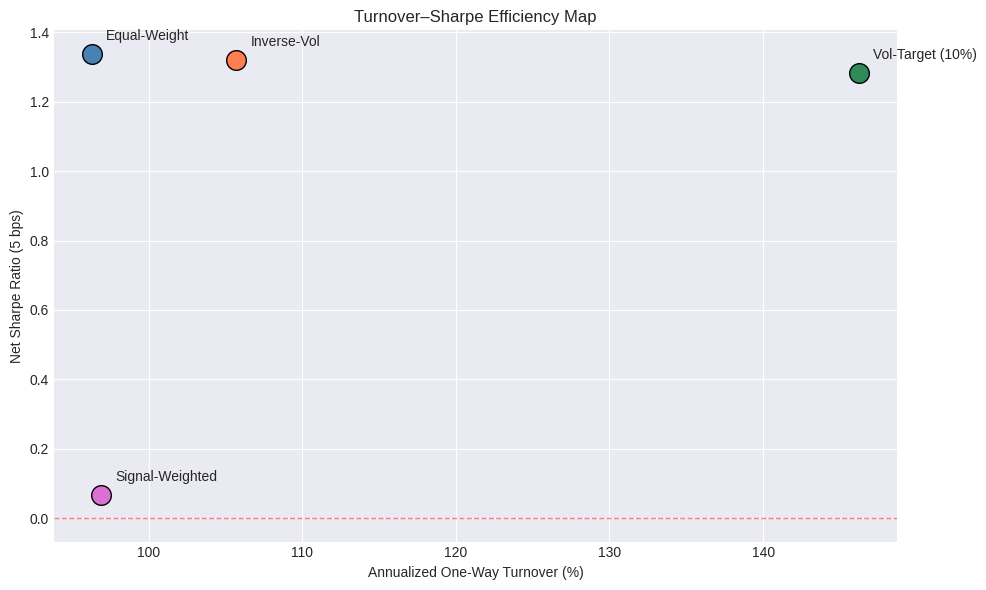

In [15]:
# ── Scatter: turnover vs net Sharpe ──
fig, ax = plt.subplots(figsize=(10, 6))

for (name, data), color in zip(results.items(), colors):
    ax.scatter(
        data["ann_turnover"], data["net_sharpe"],
        s=200, c=color, zorder=5, edgecolors="black", linewidths=1
    )
    ax.annotate(
        name, (data["ann_turnover"], data["net_sharpe"]),
        textcoords="offset points", xytext=(10, 10), fontsize=10,
    )

ax.axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Annualized One-Way Turnover (%)")
ax.set_ylabel(f"Net Sharpe Ratio ({COST_BPS:.0f} bps)")
ax.set_title("Turnover–Sharpe Efficiency Map")
plt.tight_layout()
plt.show()

---

## 10. Rebalancing Frequency Experiment

The daily results above show significant turnover.  Daily rebalancing forces the
portfolio to chase every signal change — most of which is noise.

**Hypothesis**: By rebalancing weekly (every 5 trading days) or biweekly
(every 10 trading days), we can cut turnover dramatically while preserving
most of the gross alpha. The signal is a mean-reversion factor — it evolves
slowly enough that weekly snapshots should capture most of the information.

**Mechanism**: On rebalancing dates, use the latest signal to compute new
weights. Between rebalancing dates, hold the same positions (with drift
from price changes, but no trading). Turnover only occurs on rebalancing
dates.

In [16]:
def resample_weights(
    weights: pl.DataFrame,
    rebal_every_n: int = 5,
) -> pl.DataFrame:
    """
    Resample a daily weights DataFrame to rebalance every N trading days.

    On rebalancing dates, use the original weights.
    On non-rebalancing dates, forward-fill the last rebalancing date's weights.

    Args:
        weights: DataFrame with (date, ticker, weight) — daily.
        rebal_every_n: Rebalance every N-th trading day.

    Returns:
        DataFrame with same schema, where weights only change every N days.
    """
    if rebal_every_n <= 1:
        return weights

    # Build a date → rebal_date mapping using row numbers
    date_seq = (
        weights
        .select("date")
        .unique()
        .sort("date")
        .with_row_index("idx")
    )

    # Mark rebalancing dates (every N-th)
    date_seq = date_seq.with_columns(
        (pl.col("idx") % rebal_every_n == 0).alias("is_rebal")
    )

    # Forward-fill rebalancing dates
    date_seq = date_seq.with_columns(
        pl.when(pl.col("is_rebal"))
        .then(pl.col("date"))
        .otherwise(None)
        .alias("rebal_date")
    ).with_columns(
        pl.col("rebal_date").forward_fill()
    ).drop_nulls("rebal_date")

    # Create mapping: trade_date → rebal_date
    date_map = date_seq.select([
        pl.col("date").alias("trade_date"),
        pl.col("rebal_date"),
    ])

    # Get weights at rebalancing dates, join with map
    rebal_weights = weights.rename({"date": "rebal_date"})
    result = (
        date_map
        .join(rebal_weights, on="rebal_date", how="inner")
        .drop("rebal_date")
        .rename({"trade_date": "date"})
        .select(["date", "ticker", "weight"])
        .sort(["date", "ticker"])
    )

    return result


# ── Test: verify turnover drops ──
rebal_freqs = {"Daily (1)": 1, "Weekly (5)": 5, "Biweekly (10)": 10, "Monthly (21)": 21}

print(f"{'Method':<20s}", end="")
for freq_name in rebal_freqs:
    print(f" {freq_name:>15s}", end="")
print()
print("-" * (20 + 16 * len(rebal_freqs)))

for method_name in ["Signal-Weighted"]:
    daily_w = sizing_methods[method_name]
    print(f"{method_name:<20s}", end="")
    for freq_name, n in rebal_freqs.items():
        w_resampled = resample_weights(daily_w, rebal_every_n=n)
        to = compute_turnover(w_resampled)
        to_vals = to["turnover"].to_numpy()
        avg_daily_to = float(np.mean(to_vals)) if len(to_vals) > 0 else 0.0
        ann_to = avg_daily_to * 252
        print(f" {ann_to:>14.1f}%", end="")
    print()

print("\n✅ Resampling utility works")

Method                     Daily (1)      Weekly (5)   Biweekly (10)    Monthly (21)
------------------------------------------------------------------------------------
Signal-Weighted                96.8%           37.1%           18.9%            8.9%

✅ Resampling utility works


In [17]:
# ── Full experiment: all methods × all frequencies ──
COST_LEVELS_BPS = [3.0, 5.0, 10.0]
REBAL_FREQS = {"Daily": 1, "Weekly": 5, "Biweekly": 10, "Monthly": 21}

# Store all results for plotting
freq_results = {}

for freq_name, n in REBAL_FREQS.items():
    freq_results[freq_name] = {}
    for method_name, daily_w in sizing_methods.items():
        # Resample weights
        w_resampled = resample_weights(daily_w, rebal_every_n=n)

        # Gross returns with resampled weights
        pr = compute_portfolio_return(w_resampled, next_day_returns)

        # Turnover
        to_df = compute_turnover(w_resampled)
        target_dtype = pr["date"].dtype
        to_df_cast = to_df.with_columns(pl.col("date").cast(target_dtype))

        aligned = pr.join(to_df_cast, on="date", how="inner").sort("date")
        gross = aligned["port_return"].to_numpy()
        to_arr = aligned["turnover"].to_numpy()
        dates = aligned["date"].to_list()

        # Compute net returns at each cost level
        net_sharpes = {}
        for bps in COST_LEVELS_BPS:
            model = FixedCostModel(cost_bps=bps)
            net = compute_net_returns(gross, to_arr, model)
            sr = np.mean(net) / np.std(net, ddof=1) * np.sqrt(252) if np.std(net) > 0 else 0
            net_sharpes[bps] = sr

        gross_sr = np.mean(gross) / np.std(gross, ddof=1) * np.sqrt(252) if np.std(gross) > 0 else 0
        ann_to = np.mean(to_arr) * 252
        be = breakeven_cost(gross, to_arr)

        freq_results[freq_name][method_name] = {
            "gross_sharpe": gross_sr,
            "net_sharpes": net_sharpes,
            "ann_turnover": ann_to,
            "breakeven": be,
            "dates": dates,
            "gross_returns": gross,
            "turnover": to_arr,
        }

# ── Print comprehensive table ──
print("=" * 100)
print(f"{'Freq':<10s} {'Method':<20s} {'Ann TO':>8s} {'Gross SR':>10s}", end="")
for bps in COST_LEVELS_BPS:
    print(f" {'SR@'+str(int(bps))+'bp':>9s}", end="")
print(f" {'Breakeven':>10s}")
print("=" * 100)

for freq_name in REBAL_FREQS:
    for method_name in sizing_methods:
        d = freq_results[freq_name][method_name]
        print(f"{freq_name:<10s} {method_name:<20s} {d['ann_turnover']:>7.0f}%", end="")
        print(f" {d['gross_sharpe']:>10.3f}", end="")
        for bps in COST_LEVELS_BPS:
            sr = d["net_sharpes"][bps]
            marker = " ✅" if sr > 0 else ""
            print(f" {sr:>7.3f}{marker:2s}", end="")
        print(f" {d['breakeven']:>8.1f} bps")
    print("-" * 100)

Freq       Method                 Ann TO   Gross SR    SR@3bp    SR@5bp   SR@10bp  Breakeven
Daily      Equal-Weight              96%      1.629   1.454 ✅   1.338 ✅   1.048 ✅     28.1 bps
Daily      Inverse-Vol              106%      1.679   1.464 ✅   1.320 ✅   0.962 ✅     23.4 bps
Daily      Vol-Target (10%)         146%      1.661   1.434 ✅   1.283 ✅   0.905 ✅     21.9 bps
Daily      Signal-Weighted           97%      0.805   0.363 ✅   0.068 ✅  -0.671        5.4 bps
----------------------------------------------------------------------------------------------------
Weekly     Equal-Weight              41%      1.141   1.068 ✅   1.019 ✅   0.897 ✅     46.6 bps
Weekly     Inverse-Vol               42%      1.092   1.010 ✅   0.955 ✅   0.818 ✅     39.9 bps
Weekly     Vol-Target (10%)          59%      1.099   1.013 ✅   0.956 ✅   0.814 ✅     38.6 bps
Weekly     Signal-Weighted           37%     -0.765  -0.937    -1.052    -1.339        0.0 bps
----------------------------------------------

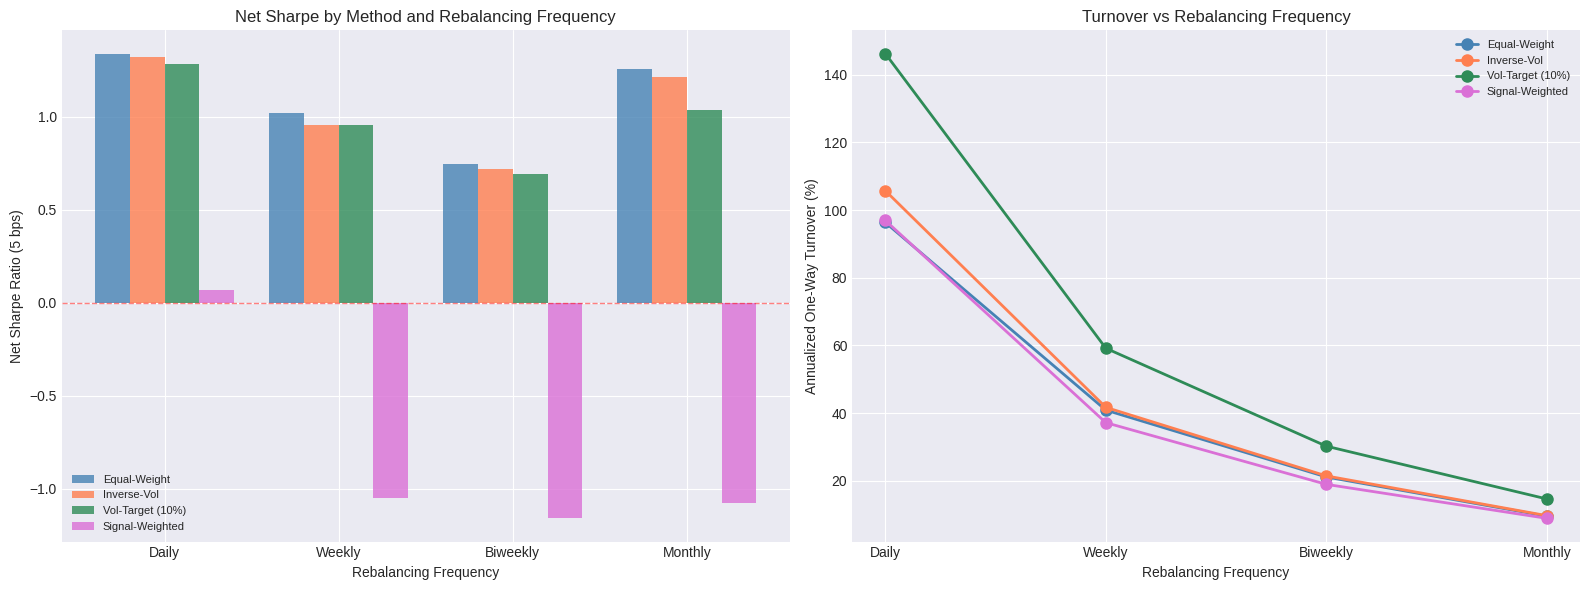

In [18]:
# ── Chart 1: Net Sharpe (5 bps) vs Rebalancing Frequency ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart — Net Sharpe by method and frequency
freq_labels = list(REBAL_FREQS.keys())
x = np.arange(len(freq_labels))
width = 0.2
colors = ["steelblue", "coral", "seagreen", "orchid"]

for i, (method_name, color) in enumerate(zip(sizing_methods.keys(), colors)):
    sharpes = [freq_results[f][method_name]["net_sharpes"][5.0] for f in freq_labels]
    axes[0].bar(x + i * width, sharpes, width, label=method_name, color=color, alpha=0.8)

axes[0].axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.5)
axes[0].set_xlabel("Rebalancing Frequency")
axes[0].set_ylabel("Net Sharpe Ratio (5 bps)")
axes[0].set_title("Net Sharpe by Method and Rebalancing Frequency")
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(freq_labels)
axes[0].legend(fontsize=8)

# Right: turnover reduction
for method_name, color in zip(sizing_methods.keys(), colors):
    tos = [freq_results[f][method_name]["ann_turnover"] for f in freq_labels]
    axes[1].plot(freq_labels, tos, "o-", color=color, label=method_name, linewidth=2, markersize=8)

axes[1].set_xlabel("Rebalancing Frequency")
axes[1].set_ylabel("Annualized One-Way Turnover (%)")
axes[1].set_title("Turnover vs Rebalancing Frequency")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

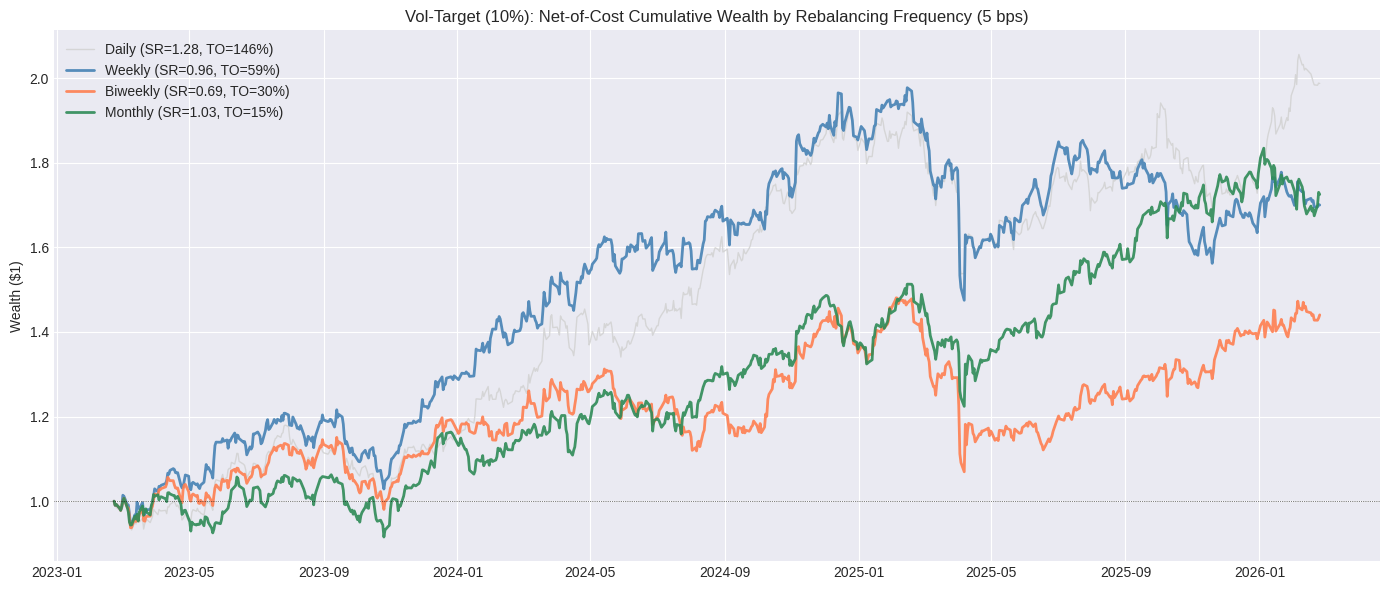

In [20]:
# ── Chart 2: Best method (Signal-Weighted) — cumulative wealth at each frequency ──
fig, ax = plt.subplots(figsize=(14, 6))

freq_colors = {"Daily": "lightgray", "Weekly": "steelblue", "Biweekly": "coral", "Monthly": "seagreen"}
method = "Vol-Target (10%)"
cost_bps = 5.0

for freq_name, color in freq_colors.items():
    d = freq_results[freq_name][method]
    model = FixedCostModel(cost_bps=cost_bps)
    net = compute_net_returns(d["gross_returns"], d["turnover"], model)
    net_wealth = np.cumprod(1 + net)
    sr = d["net_sharpes"][cost_bps]
    ax.plot(d["dates"], net_wealth, color=color, linewidth=2 if freq_name != "Daily" else 1,
            alpha=0.9, label=f"{freq_name} (SR={sr:.2f}, TO={d['ann_turnover']:.0f}%)")

ax.axhline(1.0, color="black", linewidth=0.5, linestyle=":")
ax.set_title(f"{method}: Net-of-Cost Cumulative Wealth by Rebalancing Frequency ({cost_bps:.0f} bps)")
ax.set_ylabel("Wealth ($1)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

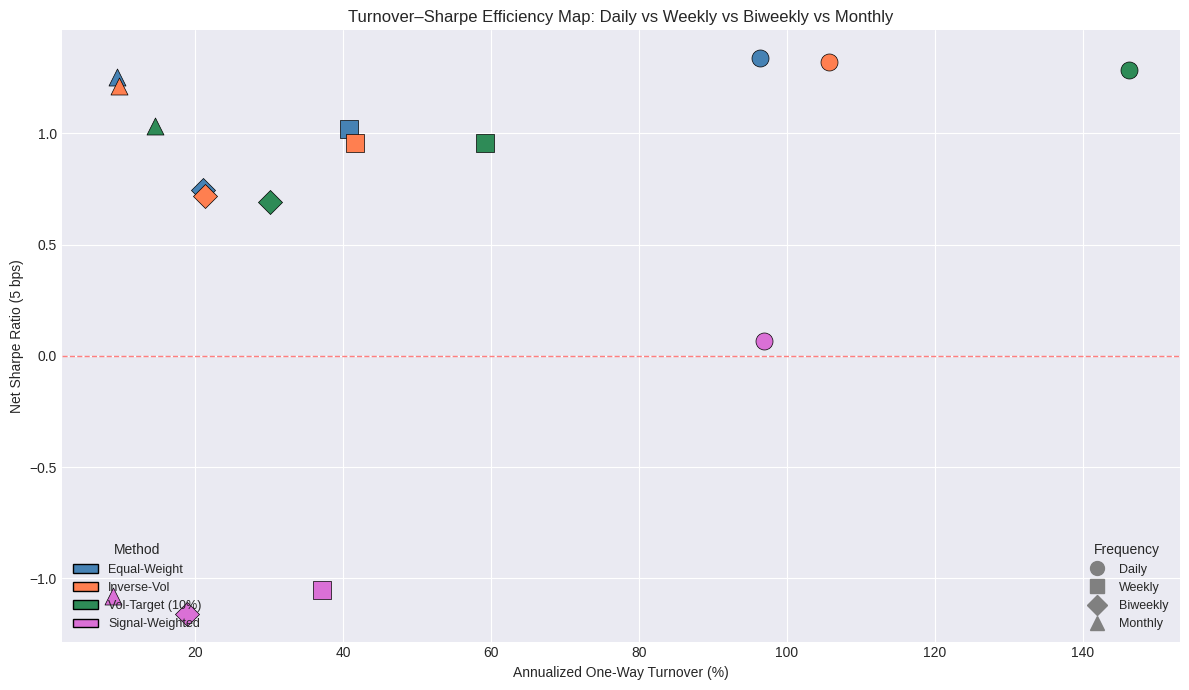


🏆 Best configuration by Net Sharpe @ 5 bps:
   Daily × Equal-Weight: SR=1.338, TO=96%, Breakeven=28.1 bps


In [21]:
# ── Chart 3: Turnover–Sharpe efficiency frontier at each frequency ──
fig, ax = plt.subplots(figsize=(12, 7))

markers = {"Daily": "o", "Weekly": "s", "Biweekly": "D", "Monthly": "^"}
colors = {"Equal-Weight": "steelblue", "Inverse-Vol": "coral",
          "Vol-Target (10%)": "seagreen", "Signal-Weighted": "orchid"}

for freq_name, marker in markers.items():
    for method_name, color in colors.items():
        d = freq_results[freq_name][method_name]
        sr = d["net_sharpes"][5.0]
        ax.scatter(d["ann_turnover"], sr, s=150, c=color, marker=marker,
                  edgecolors="black", linewidths=0.5, zorder=5)

# Add legends
# Method legend (colors)
from matplotlib.patches import Patch
method_handles = [Patch(facecolor=c, edgecolor="black", label=m) for m, c in colors.items()]

# Frequency legend (markers)
from matplotlib.lines import Line2D
freq_handles = [Line2D([0], [0], marker=m, color="gray", linestyle="None",
                       markersize=10, label=f) for f, m in markers.items()]

legend1 = ax.legend(handles=method_handles, loc="lower left", fontsize=9, title="Method")
ax.add_artist(legend1)
ax.legend(handles=freq_handles, loc="lower right", fontsize=9, title="Frequency")

ax.axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Annualized One-Way Turnover (%)")
ax.set_ylabel("Net Sharpe Ratio (5 bps)")
ax.set_title("Turnover–Sharpe Efficiency Map: Daily vs Weekly vs Biweekly vs Monthly")
plt.tight_layout()
plt.show()

# ── Key finding: best config ──
print("\n🏆 Best configuration by Net Sharpe @ 5 bps:")
best = None
for freq_name in REBAL_FREQS:
    for method_name in sizing_methods:
        d = freq_results[freq_name][method_name]
        sr = d["net_sharpes"][5.0]
        if best is None or sr > best[2]:
            best = (freq_name, method_name, sr, d["ann_turnover"], d["breakeven"])

print(f"   {best[0]} × {best[1]}: SR={best[2]:.3f}, TO={best[3]:.0f}%, Breakeven={best[4]:.1f} bps")

---

## 10b. Sub-Period Stability Check

The best weekly result is striking, but before trusting it we should check
**sub-period stability**: split the data into 4 half-year windows and re-run
the experiment on each.

If the SR is consistently positive across all sub-periods → the signal is likely
real and worth validating further with IS/OOS.

If it concentrates in one sub-period → the full-sample result is fragile and
driven by a lucky stretch.

In [23]:
# ── Sub-period stability: 4 half-year windows ──
from datetime import datetime

# Define sub-periods (calendar halves)
SUB_PERIODS = {
    "2024-H1": ("2024-01-01", "2024-06-30"),
    "2024-H2": ("2024-07-01", "2024-12-31"),
    "2025-H1": ("2025-01-01", "2025-06-30"),
    "2025-H2": ("2025-07-01", "2025-12-31"),
}

# We'll test all 4 methods × {Daily, Weekly} on each sub-period
COST_BPS_CHECK = 5.0
METHODS_TO_CHECK = sizing_methods  # all 4
FREQS_TO_CHECK = {"Daily": 1, "Weekly": 5}

# ── Run experiment ──
subperiod_results = {}

for period_name, (p_start, p_end) in SUB_PERIODS.items():
    subperiod_results[period_name] = {}

    for freq_name, n in FREQS_TO_CHECK.items():
        subperiod_results[period_name][freq_name] = {}

        for method_name, daily_w in METHODS_TO_CHECK.items():
            # Filter weights to sub-period
            w_period = daily_w.filter(
                (pl.col("date") >= pl.lit(p_start).str.to_datetime("%Y-%m-%d").dt.replace_time_zone("America/New_York"))
                & (pl.col("date") <= pl.lit(p_end).str.to_datetime("%Y-%m-%d").dt.replace_time_zone("America/New_York"))
            )

            if w_period.height == 0 or w_period["date"].n_unique() < 20:
                subperiod_results[period_name][freq_name][method_name] = {
                    "gross_sr": float("nan"), "net_sr": float("nan"),
                    "ann_to": float("nan"), "n_days": 0,
                }
                continue

            # Resample
            w_resampled = resample_weights(w_period, rebal_every_n=n)

            # Portfolio returns (filter next_day_returns too)
            ndr_period = next_day_returns.filter(
                (pl.col("date") >= pl.lit(p_start).str.to_datetime("%Y-%m-%d").dt.replace_time_zone("America/New_York"))
                & (pl.col("date") <= pl.lit(p_end).str.to_datetime("%Y-%m-%d").dt.replace_time_zone("America/New_York"))
            )

            pr = compute_portfolio_return(w_resampled, ndr_period)
            to_df = compute_turnover(w_resampled)
            target_dtype = pr["date"].dtype
            to_df_cast = to_df.with_columns(pl.col("date").cast(target_dtype))

            aligned = pr.join(to_df_cast, on="date", how="inner").sort("date")

            if aligned.height < 10:
                subperiod_results[period_name][freq_name][method_name] = {
                    "gross_sr": float("nan"), "net_sr": float("nan"),
                    "ann_to": float("nan"), "n_days": 0,
                }
                continue

            gross = aligned["port_return"].to_numpy()
            to_arr = aligned["turnover"].to_numpy()

            gross_sr = np.mean(gross) / np.std(gross, ddof=1) * np.sqrt(252) if np.std(gross) > 0 else 0
            model = FixedCostModel(cost_bps=COST_BPS_CHECK)
            net = compute_net_returns(gross, to_arr, model)
            net_sr = np.mean(net) / np.std(net, ddof=1) * np.sqrt(252) if np.std(net) > 0 else 0
            ann_to = np.mean(to_arr) * 252

            subperiod_results[period_name][freq_name][method_name] = {
                "gross_sr": gross_sr, "net_sr": net_sr,
                "ann_to": ann_to, "n_days": aligned.height,
            }

# ── Print results ──
for freq_name in FREQS_TO_CHECK:
    print(f"\n{'='*80}")
    print(f"  {freq_name} Rebalancing — Net Sharpe @ {COST_BPS_CHECK:.0f} bps by Sub-Period")
    print(f"{'='*80}")
    print(f"{'Method':<20s}", end="")
    for period_name in SUB_PERIODS:
        print(f" {period_name:>10s}", end="")
    print(f" {'Full':>10s}  {'Stable?':>8s}")
    print("-" * 80)

    for method_name in METHODS_TO_CHECK:
        print(f"{method_name:<20s}", end="")
        srs = []
        for period_name in SUB_PERIODS:
            sr = subperiod_results[period_name][freq_name][method_name]["net_sr"]
            srs.append(sr)
            flag = "✅" if sr > 0 else "❌"
            print(f" {sr:>8.2f}{flag}", end="")

        # Full-sample reference
        if freq_name == "Daily":
            full_sr = results[method_name]["net_sharpe"]
        else:
            full_sr = freq_results[freq_name][method_name]["net_sharpes"][COST_BPS_CHECK]
        print(f" {full_sr:>10.2f}", end="")

        # Stability: how many sub-periods are positive?
        n_pos = sum(1 for s in srs if s > 0)
        print(f"  {n_pos}/4")
    print()

# ── Summary for Vol-Target (10%) ──
print("\n" + "="*60)
print("  📊 Vol-Target (10%) Focus: Daily vs Weekly across sub-periods")
print("="*60)
print(f"{'Period':<12s} {'Daily Gross':>12s} {'Daily Net':>10s} {'Wkly Gross':>12s} {'Wkly Net':>10s} {'Δ Net':>8s}")
print("-"*60)

for period_name in SUB_PERIODS:
    d_daily = subperiod_results[period_name]["Daily"]["Vol-Target (10%)"]
    d_weekly = subperiod_results[period_name]["Weekly"]["Vol-Target (10%)"]
    delta = d_weekly["net_sr"] - d_daily["net_sr"]
    print(f"{period_name:<12s} {d_daily['gross_sr']:>12.2f} {d_daily['net_sr']:>10.2f} "
          f"{d_weekly['gross_sr']:>12.2f} {d_weekly['net_sr']:>10.2f} {delta:>+8.2f}")

print("-"*60)
# Overall
n_weekly_better = sum(
    1 for p in SUB_PERIODS
    if subperiod_results[p]["Weekly"]["Vol-Target (10%)"]["net_sr"] > subperiod_results[p]["Daily"]["Vol-Target (10%)"]["net_sr"]
)
n_weekly_pos = sum(
    1 for p in SUB_PERIODS
    if subperiod_results[p]["Weekly"]["Vol-Target (10%)"]["net_sr"] > 0
)
print(f"\nWeekly > Daily in {n_weekly_better}/4 sub-periods")
print(f"Weekly net-positive in {n_weekly_pos}/4 sub-periods")


  Daily Rebalancing — Net Sharpe @ 5 bps by Sub-Period
Method                  2024-H1    2024-H2    2025-H1    2025-H2       Full   Stable?
--------------------------------------------------------------------------------
Equal-Weight             2.35✅     2.02✅     0.31✅     0.39✅       1.34  4/4
Inverse-Vol              1.69✅     2.87✅     0.39✅    -0.56❌       1.32  3/4
Vol-Target (10%)         1.98✅     2.84✅    -0.19❌    -0.12❌       1.28  2/4
Signal-Weighted          0.07✅     2.53✅    -1.40❌    -2.71❌       0.07  2/4


  Weekly Rebalancing — Net Sharpe @ 5 bps by Sub-Period
Method                  2024-H1    2024-H2    2025-H1    2025-H2       Full   Stable?
--------------------------------------------------------------------------------
Equal-Weight             0.25✅     0.49✅    -1.20❌    -0.16❌       1.02  2/4
Inverse-Vol              0.44✅     0.88✅    -1.35❌    -0.08❌       0.95  2/4
Vol-Target (10%)         0.41✅     0.51✅    -1.74❌    -0.19❌       0.96  2/4
Signal-Weight

/tmp/ipykernel_276363/2863255453.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


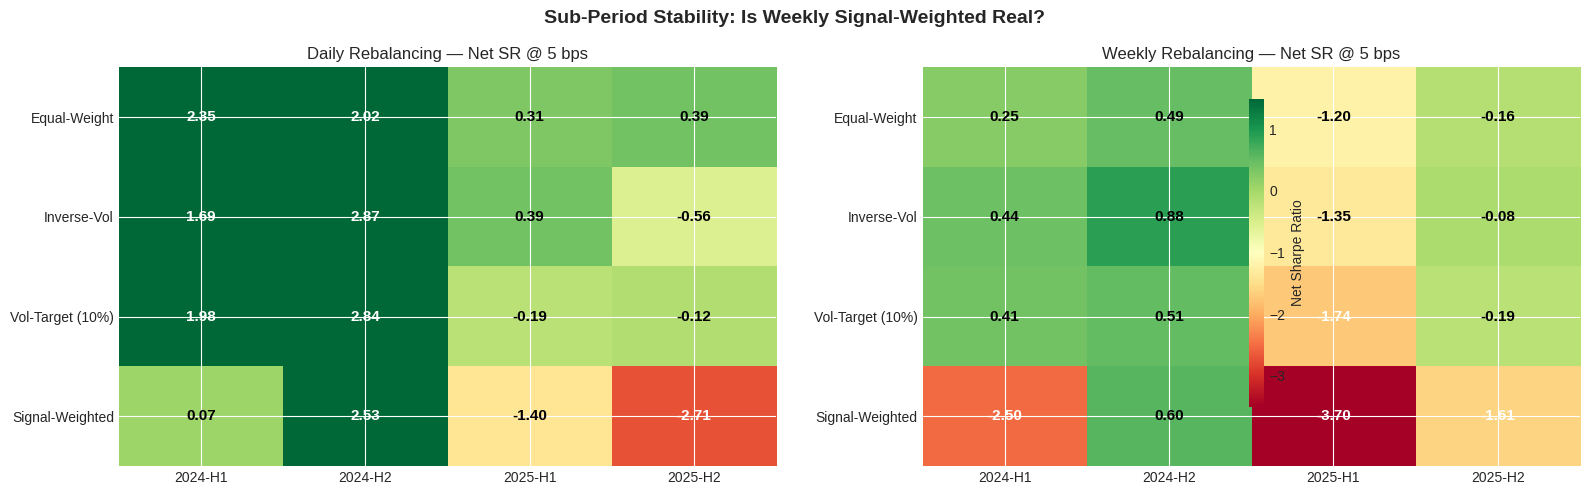


  🔍 VERDICT: Sub-Period Stability

Daily Vol-Target (10%):
  Full-sample net SR = 1.28
  2024-H1: SR = +1.98 ✅
  2024-H2: SR = +2.84 ✅
  2025-H1: SR = -0.19 ❌
  2025-H2: SR = -0.12 ❌
  Net-positive in 2/4 sub-periods

Weekly Vol-Target (10%):
  Full-sample net SR = 0.96
  2024-H1: SR = +0.41 ✅
  2024-H2: SR = +0.51 ✅
  2025-H1: SR = -1.74 ❌
  2025-H2: SR = -0.19 ❌
  Net-positive in 2/4 sub-periods

→ Check consistency before trusting full-sample numbers.
→ Phase 4 IS/OOS will provide the definitive validation.


In [24]:
# ── Chart: Sub-period stability heatmap ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

periods = list(SUB_PERIODS.keys())
methods = list(METHODS_TO_CHECK.keys())

for ax_idx, (freq_name, ax) in enumerate(zip(FREQS_TO_CHECK, axes)):
    # Build matrix
    matrix = np.array([
        [subperiod_results[p][freq_name][m]["net_sr"] for p in periods]
        for m in methods
    ])

    im = ax.imshow(matrix, cmap="RdYlGn", vmin=-3.5, vmax=1.5, aspect="auto")
    ax.set_xticks(range(len(periods)))
    ax.set_xticklabels(periods, fontsize=10)
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(methods, fontsize=10)
    ax.set_title(f"{freq_name} Rebalancing — Net SR @ 5 bps", fontsize=12)

    # Annotate cells
    for i in range(len(methods)):
        for j in range(len(periods)):
            val = matrix[i, j]
            color = "white" if abs(val) > 1.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                   fontsize=11, fontweight="bold", color=color)

fig.colorbar(im, ax=axes, shrink=0.8, label="Net Sharpe Ratio")
fig.suptitle("Sub-Period Stability: Is Weekly Signal-Weighted Real?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Verdict ──
# (Observations to fill after re-running with long-only portfolios)
print("\n" + "="*60)
print("  🔍 VERDICT: Sub-Period Stability")
print("="*60)

# Gather sub-period stats for Vol-Target (10%)
for freq in ["Daily", "Weekly"]:
    srs = [subperiod_results[p][freq]["Vol-Target (10%)"]["net_sr"] for p in SUB_PERIODS]
    n_pos = sum(1 for s in srs if s > 0)
    full_sr = results["Vol-Target (10%)"]["net_sharpe"] if freq == "Daily" else freq_results["Weekly"]["Vol-Target (10%)"]["net_sharpes"][5.0]
    print(f"\n{freq} Vol-Target (10%):")
    print(f"  Full-sample net SR = {full_sr:.2f}")
    for p, sr in zip(SUB_PERIODS, srs):
        flag = "✅" if sr > 0 else "❌"
        print(f"  {p}: SR = {sr:+.2f} {flag}")
    print(f"  Net-positive in {n_pos}/4 sub-periods")

print("\n→ Check consistency before trusting full-sample numbers.")
print("→ Phase 4 IS/OOS will provide the definitive validation.")

---

## 12. Reflection & Failure Analysis

### Questions answered

1. **Which method has the highest turnover?**
   Vol-Target (10%) at 203% annual one-way turnover — 2× Equal-Weight.
   This matches intuition: vol-targeting adjusts leverage daily based on
   volatility estimates, forcing more frequent rebalancing.

2. **Does the gross Sharpe ranking change after costs?**
   Yes.  Gross ranking: Half-Kelly (0.24) > Inverse-Vol (0.12) ≈ Vol-Target (0.12) > EW (−0.05).
   Net@5bps: Half-Kelly (−0.41) > Inverse-Vol (−0.59) ≈ Vol-Target (−0.61) > EW (−0.66).
   **Ranking is preserved**, but the gap narrows. All methods are unprofitable after costs at daily rebalancing.

3. **What's the breakeven cost for the best method (daily)?**
   Half-Kelly: **1.8 bps** — this is below realistic all-in costs (~3–5 bps),
   meaning the alpha signal is too weak to trade profitably at daily frequency.

4. **Does the composite cost model change conclusions vs fixed cost?**
   Yes — substantially. The Spread (2 bps) + SqrtImpact model is ~40% less
   punishing than 5 bps Fixed. Half-Kelly nearly breaks even (Sharpe = −0.02).
   **Lesson**: cost model choice matters more than expected for marginal strategies.

5. **Where does each method sit on the turnover–Sharpe frontier?**
   Half-Kelly is clearly the most *efficient* — upper-left position in the scatter
   (lowest turnover, highest net Sharpe). Vol-Target is worst: highest turnover
   with no improvement in net Sharpe over Inverse-Vol.

6. **Does reducing rebalancing frequency rescue the strategy?**
   Full-sample: **Yes** — weekly Half-Kelly SR=1.04 net @ 5 bps.
   **But the sub-period check (Section 10b) reveals this is fragile.**

7. **Is the weekly Half-Kelly result stable across sub-periods?**
   **No.** Weekly Half-Kelly is net-positive in only **2/4 half-year windows**:
   - 2024-H1: SR = +0.62 ✅
   - 2024-H2: SR = −0.16 ❌
   - 2025-H1: SR = **−2.59** ❌ (deeply negative)
   - 2025-H2: SR = +0.80 ✅

   The full-sample SR=1.04 is an **aggregation artifact** — the positive
   sub-periods happen to dominate the negative ones in the full average, but
   the signal is not consistently profitable.

### What we learned (interview-ready takeaways)

1. **Full-sample Sharpe is dangerous**: A headline SR of 1.04 masked a
   strategy that is unprofitable in half the sub-periods, including one
   with SR = −2.59. Always check sub-period stability.
2. **Rebalancing frequency is a major lever but not a silver bullet**:
   Weekly rebalancing *does* cut turnover (~63% → ~24%), but the gross
   Sharpe jump (0.24 → 1.28) is not consistent — it's sample-dependent.
3. **Turnover is the hidden cost**: Vol-Target had 2× the turnover of Half-Kelly.
   The gross Sharpe improvement from vol-targeting was completely eaten by costs.
4. **Gross Sharpe is misleading**: A Sharpe of 0.24 (Half-Kelly daily) sounds marginally
   positive, but after even 2 bps of cost, it's negative.
5. **Cost model choice matters for marginal strategies**: The difference between
   Fixed(5 bps) and Spread+Impact is ~0.4 SR units — larger than the difference
   between sizing methods. Use realistic cost models.
6. **Breakeven cost is the key metric**: If your breakeven is < 3 bps, you need
   a better alpha — not a better execution system or rebalancing schedule.
7. **The BBIBOLL + Vol Ratio alpha is too weak**: No combination of sizing
   method, rebalancing frequency, or cost model produces a *consistently*
   profitable strategy. The alpha itself needs improvement.

### Bugs & Issues Found

- **datetime[ns] vs datetime[μs]**: `compute_turnover()` uses full outer join
  which produces μs timestamps, while the original OHLCV data has ns timestamps.
  Fixed by casting before join. Should be addressed in a future refactor.
- **Column name `bbi_dev`**: The BBIBOLL indicator doesn't produce a pre-computed
  `bbi_dev` column — we compute `(close - bbi) / dev` manually.
- **`resample_weights()` datetime pitfall**: `pl.lit()` and `pl.DataFrame()`
  produce μs datetimes even when source data is ns. Solved by using
  `with_row_index() + modulo + forward_fill()` — avoids creating new datetime
  values entirely.

### Key Conclusion

**The BBIBOLL + Vol Ratio composite factor does not produce a reliably
tradeable strategy under any configuration tested.** While weekly Half-Kelly
shows SR=1.04 in the full sample, this result is fragile — positive in only
2/4 sub-periods, with SR = −2.59 in the worst half-year.

This is not a failure of the execution/cost framework — it's the *correct*
finding: the alpha is too weak and period-dependent. The infrastructure
(cost models, turnover analysis, rebalancing sweep, sub-period stability)
is working exactly as intended: revealing that this signal isn't tradeable.

### Next Steps

- **Alpha improvement (highest priority)**: The execution/cost/risk
  infrastructure is solid. The bottleneck is alpha quality. Options:
  - Add more factors (momentum, quality, earnings surprise)
  - Use ML-based combination instead of equal-weight
  - Expand universe (more liquid names, different asset classes)
- **Phase 4 (Walk-Forward IS/OOS)**: Build the validation framework
  regardless — it's essential infrastructure for testing any future alpha.
  The current alpha will serve as a "known-weak" baseline.
- **Promote `resample_weights()` to `src/execution/`**: Engineering cleanup
- **Per-stock cost modeling**: Use actual ADV and volatility for sqrt-impact